In [ ]:
import scanpy as sc
import re
import numpy as np
import gc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import pycircos
import collections
import textwrap
import matplotlib

def similar_color(base_color, variance=0.2):
    perturbation = (np.random.rand(3) - 0.5) * 2 * variance
    new_color = base_color[:3] + perturbation
    new_color = np.clip(new_color, 0, 1)
    return np.append(new_color, 1)  # Append alpha value

def assign_colors(group_subgroup_dict):
    num_groups = len(group_subgroup_dict)
    group_colors = plt.cm.get_cmap('tab20', num_groups)
    all_colors = {}

    for i, (group_name, subgroups) in enumerate(group_subgroup_dict.items()):
        group_color = np.append(group_colors(i)[:3], 1)  # Append alpha value
        subgroup_colors = []

        for _ in subgroups['subgroup']:
            subgroup_color = similar_color(group_color)
            subgroup_colors.append(subgroup_color)  # Convert to tuple

        all_colors[group_name] = {
            "GroupColor": tuple(group_color),  # Convert to tuple
            "SubgroupColors": subgroup_colors
        }

    return all_colors

def plot_colors(all_colors):
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (group, colors) in enumerate(all_colors.items()):
        ax.plot([i]*2, [0, 0.5], color=colors["GroupColor"], linewidth=10)
        for j, subgroup_color in enumerate(colors["SubgroupColors"]):
            ax.plot(i, 1+j*0.1, marker='o', color=subgroup_color, markersize=10)

    ax.set_xlim(-1, len(all_colors))
    ax.set_ylim(-0.5, 2.5)
    ax.set_yticks([])
    ax.set_xticks(range(len(all_colors)))
    ax.set_xticklabels(all_colors.keys(), rotation=45, ha='right')
    plt.show()

reference_dir = '../../../data/GBM_LEAP_annotations/'

In [ ]:
# Load main atlas

adata = sc.read_h5ad(os.path.join(reference_dir, 'GBM_LEAP_annotations_v2.22_04_25.webatlas.h5ad'))

# Circos plot

In [ ]:
groups = ['Astrocytes', 'Lymphocytes', 'Myeloid', 'Neurons (Exc)', 
              'Neurons (Inh)', 'OPCs', 'Oligodendrocytes', 'Vascular-associated',
         'AC-progenitor-like', 'AC-gliosis-like', 'Gliosis-like',  'Hypoxic', 'NPC-neuronal-like',
          'OPC-NPC-like', 'OPC-like', 'OPC-neuronal-like', 'Proliferative']

In [ ]:
# subgroups
annotation_info = adata.obs.groupby(['cell_status', 'annotation_granular', 'annotation_coarse'])['cell_id'].count()
annotation_info = annotation_info[annotation_info>0].reset_index()

annotation_info = annotation_info[annotation_info['annotation_coarse'].isin(groups)].reset_index(drop=True)\
    .sort_values(['cell_status', 'annotation_coarse',  'annotation_granular'])
annotation_info['cumsum'] = np.cumsum(annotation_info['cell_id'])

start = []
for group in groups:
    df = annotation_info[annotation_info['annotation_coarse']==group].copy()
    df['start'] = np.cumsum(df['cell_id'])-df['cell_id']
    start.append(df)
annotation_info['start'] = pd.concat(start)['start']

# main groups
annotation_info_coarse = adata.obs.groupby(['cell_status', 'annotation_coarse'])['cell_id'].count()
annotation_info_coarse = annotation_info_coarse[annotation_info_coarse>0].reset_index()
annotation_info_coarse = annotation_info_coarse[annotation_info_coarse['annotation_coarse'].isin(groups)].reset_index(drop=True)\
    .sort_values(['cell_status', 'annotation_coarse'])

# cell status
annotation_info_status = annotation_info_coarse.groupby(['cell_status'])['cell_id'].sum().reset_index()

/tmp/ipykernel_567019/2593630717.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  annotation_info = adata.obs.groupby(['cell_status', 'annotation_granular', 'annotation_coarse'])['cell_id'].count()
/tmp/ipykernel_567019/2593630717.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  annotation_info_coarse = adata.obs.groupby(['cell_status', 'annotation_coarse'])['cell_id'].count()
/tmp/ipykernel_567019/2593630717.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adop

/tmp/ipykernel_567019/4164762721.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  group_colors = plt.cm.get_cmap('tab20', num_groups)


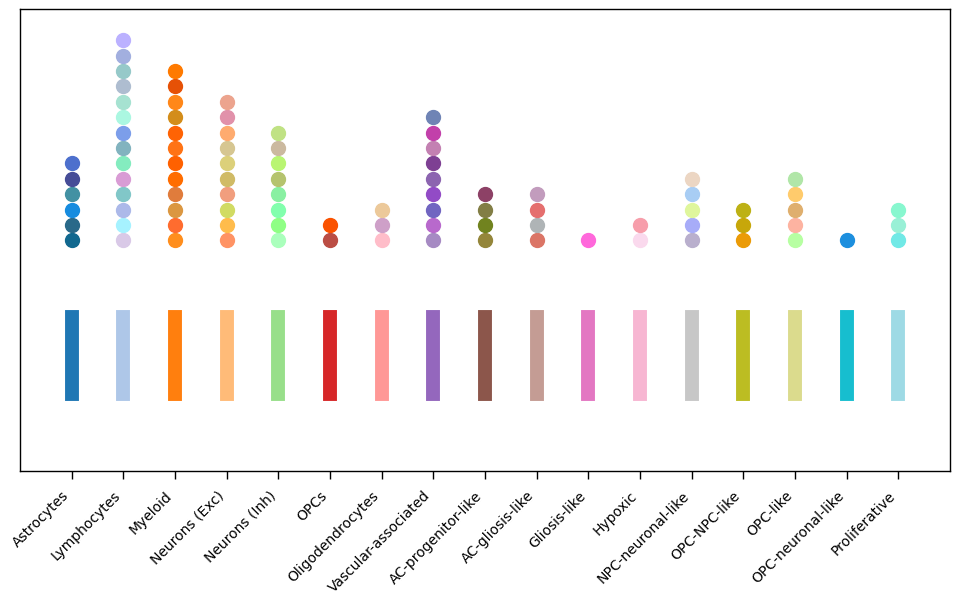

In [ ]:
# Provided dictionary
group_dict = {}
# manual group order to ensure proper colours
for group in groups:
    df = annotation_info[annotation_info['annotation_coarse']==group]
    group_dict[group] = {'subgroup':sorted(list(df['annotation_granular']))}

# Generate and plot colors
all_colors = assign_colors(group_dict)
#for i in ['AC-progenitor-like', 'AC-gliosis-like', 'Gliosis-like',  'Hypoxic']:
#    all_colors[i]['GroupColor'] = all_colors['AC-gliosis-like']['GroupColor']
plot_colors(all_colors)

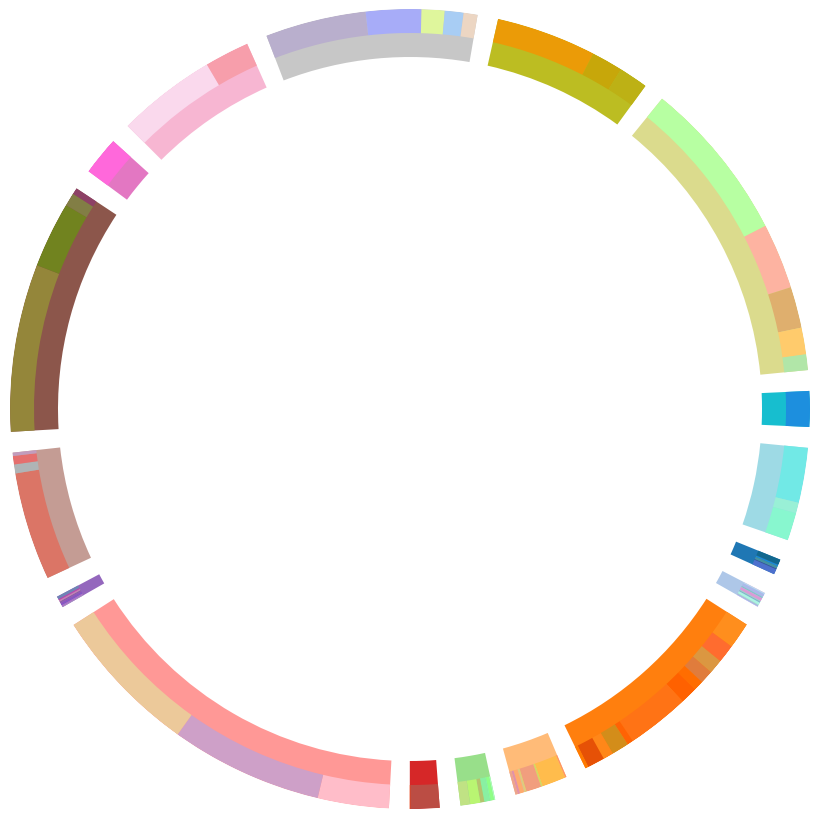

In [ ]:
# Circos generation
Garc    = pycircos.Garc
Gcircle = pycircos.Gcircle

circle = Gcircle(figsize=(8,8))

edited_names = {}
for i in range(len(annotation_info_coarse)):
    line = annotation_info_coarse.loc[[i]]
    length = line['cell_id'].item()
    name = line['annotation_coarse'].item()
    
    if length<30000:
        name_edit = line['annotation_coarse'].str.wrap(11).item()
    else:
        name_edit = line['annotation_coarse'].item()
    edited_names[name] = name_edit # add names to ensure visibility
        
    if name=='Astrocytes':
        labelposition = 200
    else:
        labelposition = 120
    
    arc = Garc(arc_id=name_edit, size=length, interspace=3, raxis_range=(880,1000), 
               labelposition=labelposition, label_visible=False, facecolor = all_colors[name]['GroupColor'], 
               linewidth=0, labelsize=11)
    circle.add_garc(arc)
    
circle.set_garcs(-115,245) 
#for arc_id in circle.garc_dict:
#    circle.tickplot(arc_id, raxis_range=[900,1000], tickinterval=20000000, ticklabels=None) 
circle.figure

arcdata_dict = collections.defaultdict(dict)
for group in groups:
    df = annotation_info[annotation_info['annotation_coarse']==group].reset_index(drop=True)
    name = group
    
    # add editted names to properly add key
    name_edit = edited_names[name]
    
    for i in range(len(df['annotation_granular'])):
        start = df.loc[i]['start'].item()
        width = df.loc[i]['cell_id'].item()
        color = all_colors[name]['SubgroupColors'][i]
        if name_edit not in arcdata_dict:
            arcdata_dict[name_edit]["positions"] = []
            arcdata_dict[name_edit]["widths"]    = [] 
            arcdata_dict[name_edit]["colors"]    = [] 
        arcdata_dict[name_edit]["positions"].append(start) 
        arcdata_dict[name_edit]["widths"].append(width)
        arcdata_dict[name_edit]["colors"].append(color)

for key in arcdata_dict:
    circle.barplot(key, data=[1]*len(arcdata_dict[key]["positions"]), positions=arcdata_dict[key]["positions"], 
                       width=arcdata_dict[key]["widths"], raxis_range=[940,1000], facecolor=arcdata_dict[key]["colors"])

In [ ]:
# Second Ring
for i in range(len(annotation_info_coarse)):
    line = annotation_info_coarse.loc[[i]]
    name = line['annotation_coarse'].item() + "_second_ring"  # Add a suffix to differentiate from the first ring
    length = line['cell_id'].item()
    arc = Garc(arc_id=name, size=length, interspace=0, raxis_range=(840,860), labelposition=75, label_visible=False)  # Adjust raxis_range
    circle.add_garc(arc)

# Second Ring Data
arcdata_dict_second_ring = collections.defaultdict(dict)
for group in groups:
    df = annotation_info[annotation_info['annotation_coarse']==group].reset_index(drop=True)
    name = group
    
    # add editted names to properly add key
    name_edit = edited_names[name]
    for i in range(len(df['annotation_granular'])):
        start = df.loc[i]['start'].item()
        width = df.loc[i]['cell_id'].item()

        if df.loc[i]['cell_status']=='Malignant':
            color = 'orangered'
        else:
            color = 'deepskyblue'
        if name_edit not in arcdata_dict_second_ring:
            arcdata_dict_second_ring[name_edit]["positions"] = []
            arcdata_dict_second_ring[name_edit]["widths"]    = [] 
            arcdata_dict_second_ring[name_edit]["colors"]    = [] 
        arcdata_dict_second_ring[name_edit]["positions"].append(start) 
        arcdata_dict_second_ring[name_edit]["widths"].append(width)
        arcdata_dict_second_ring[name_edit]["colors"].append(color)

# Plotting Second Ring Data
for key in arcdata_dict_second_ring:
    circle.barplot(key, data=[1]*len(arcdata_dict_second_ring[key]["positions"]), 
                   positions=arcdata_dict_second_ring[key]["positions"], 
                   width=arcdata_dict_second_ring[key]["widths"], raxis_range=[840,860], 
                   facecolor=arcdata_dict_second_ring[key]["colors"])  # Adjust raxis_range
    

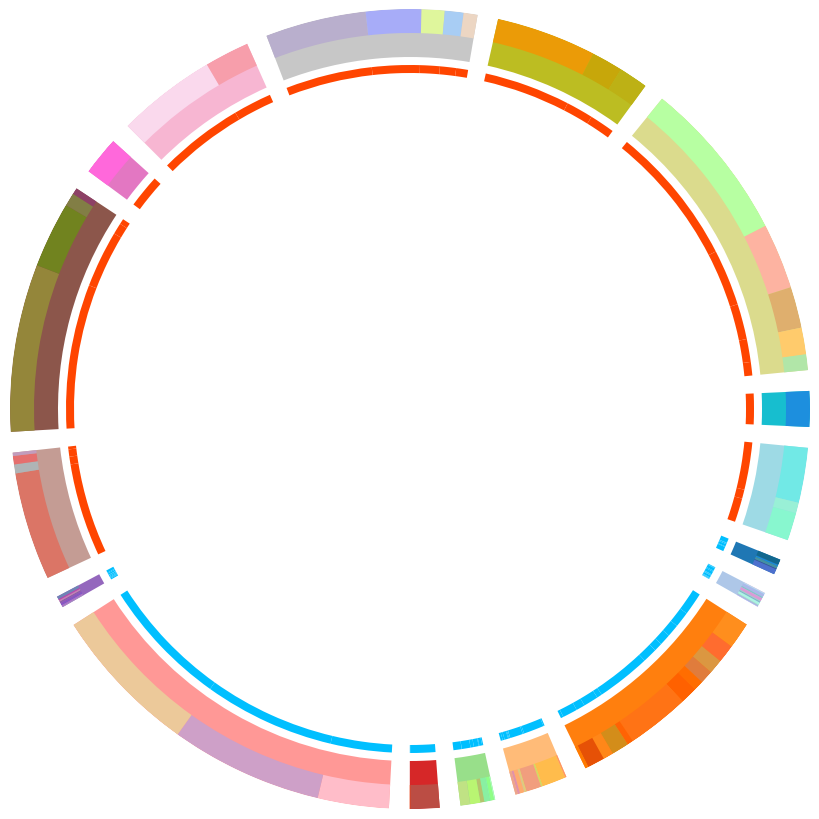

In [ ]:
circle.figure

In [ ]:
# circle.figure.savefig("../../../data/plots/fig1b_1.pdf", pad_inches=1, bbox_inches="tight", dpi=800)

# UMAP

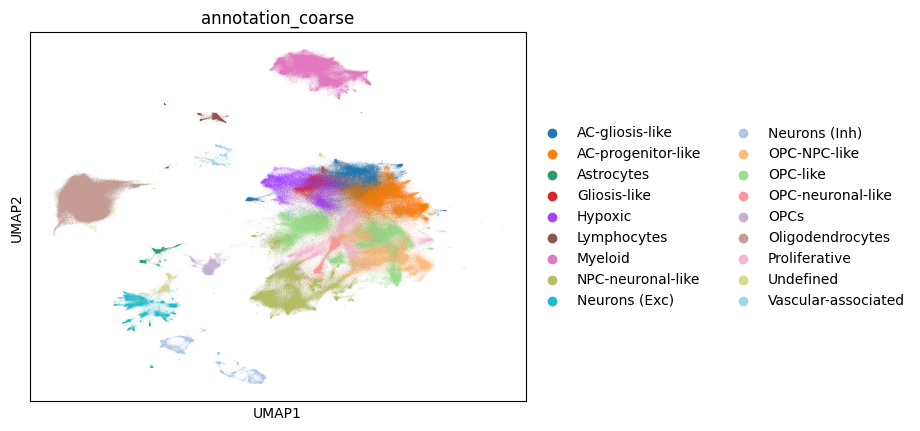

In [ ]:
sc.pl.umap(adata, color = 'annotation_coarse')